# First parameter estimation

## Unit system

The model flux equation is:

    v [mmol/(gDCW*h)] = kcat [mmol/(mg_prot*h)] * e [mg_prot/gDCW] * kappa * gamma

Enzyme concentrations (Data/important_proteins.csv) are in mg_prot/gDCW, so kcat
must be in mmol/(mg_prot*h). Table IV reports kcat both in s^-1 and converted:

    kcat [mmol/(mg_prot*h)] = kcat_s [1/s] * 3600 [s/h] / MW [g/mol]

(1/s * s/h / (g/mol) = mol/(g*h) = mmol/(mg*h), numerically identical.)
Example: FBA kcat = 10.33 s^-1, MW = 39147 g/mol -> 0.95 mmol/(mg_prot*h).
v_max_1 (PTS) is in mmol/(gDCW*h) directly (empirical formulation).

## Parameter split: 21 literature + 16 sampled

1. **Literature (21 params)** -- the non-"--" entries of **Table IV** (the
   sourced table: EcoCyc / Kadir / Equilibrator). Used verbatim. Km in mM,
   kcat in mmol/(mg_prot*h), v_max_1 in mmol/(gDCW*h).

2. **Sampled (16 params)** -- Drawn from Bar-Even (2011) **central-CE metabolism** The paper
   gives distributions for kcat and kcat/Km, so Km follows the linkage
   Km = kcat / (kcat/Km):
   - **kcat (5 params)**: lognormal(median=79 s^-1, range [50, 90]),
     converted to mmol/(mg_prot*h) via kcat_s * 3600 / MW_g_per_mol.
   - **Km linked to sampled kcat (8 params)**: Km = kcat_s / kcat_kM with
     kcat_kM ~ lognormal(median=410 mM^-1 s^-1, range [300, 500]). Implied
     Km median = 79/410 = 0.19 mM.
   - **Km for FBA and TPI (3 params)**: their kcat is literature, so these Km
     are sampled directly from the general Km set, lognormal(median=0.5 mM,
     range [0.01, 0.7]) (Bar-Even Fig 1C).

## References

- Bar-Even A. et al. (2011) Biochemistry 50(21):4402-4410. Fig 2 (central-CE
  metabolism kcat and kcat/Km medians), Fig 1C (general Km).


In [1]:
import sys
import os
import json
import pickle
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib

# matplotlib.use("Agg")
import matplotlib.pyplot as plt

# warnings.filterwarnings("ignore")

_REPO_ROOT = os.path.abspath(os.path.dirname("__file__"))
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from kinetics_noor import ALL_PARAMS
from param_estimation_parmest import (
    GlycolysisParameterEstimator,
    available_conditions,
    check_solver,
    THETA_BOUNDS,
    ALL_PARAMS as ALL_PARAMS_est,
)

# Tunable globals
SEED = 0
SIGMA_LOG10 = 0.5

_REPO_ROOT = os.path.abspath(".")  # notebook runs from repo root
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "first_estimation")
os.makedirs(RESULTS_DIR, exist_ok=True)

# All 22 experimental conditions from the Ishii dataset.
# To use a subset for faster prototyping, replace with e.g.:
#   CONDITIONS = ["KO02", "KO03", "KO05"]
CONDITIONS = np.random.choice(available_conditions(), size=22, replace=False).tolist()
if available_conditions()[-1] not in CONDITIONS:
    CONDITIONS.append(available_conditions()[-1])  # always include WT
print("ALL_PARAMS count:", len(ALL_PARAMS))
print("CONDITIONS (%d):" % len(CONDITIONS), CONDITIONS)

ALL_PARAMS count: 37
CONDITIONS (22): ['KO03', 'KO07', 'KO18', 'KO19', 'KO24', 'KO13', 'KO17', 'KO15', 'KO05', 'KO23', 'KO16', 'KO14', 'KO08', 'KO22', 'RF03', 'KO20', 'KO12', 'KO21', 'KO11', 'KO10', 'KO04', 'KO02']


## Parameter catalogue and Bar-Even sampler


Central-CE medians: kcat = 79 s^-1 (vs 13.7 global); kcat/Km = 410
mM^-1 s^-1 (= 4.1e5 M^-1 s^-1; vs 1.25e5 global). Implied Km median = 0.19 mM.
Each quantity is drawn from a lognormal whose width comes from a 95% interval
[lo, hi]: sigma = (ln(hi) - ln(lo)) / (2 * 1.96). 

In [2]:
# Literature parameters 
TABLE_IV_THETA = {
    # PTS -- Kadir et al. 2010
    "v_max_1": 25.739, "Ka1_1": 1.0, "Ka2_1": 0.01, "Ka3_1": 1.0, "K_g6p_1": 0.5,
    # PGI -- Pgi (EcoCyc EG10702); Km^f6p = 0.078 (same study as Km^g6p; 0.2 also reported)
    "Ks_g6p_pgi": 1.018, "Kp_f6p_pgi": 0.078,
    # PFK -- PfkB (EcoCyc EG10700)
    "Ks_f6p_3": 0.013, "Ks_atp_3": 0.02, "Kp_fbp_3": 0.14,
    # FBA -- FbaA (EcoCyc EG10282); kcat 10.33 s^-1 -> 0.95 mmol/(mg*h)
    "Ks_fbp_4": 0.24, "kcat_f_4": 0.95,
    # TPI -- TpiA (EcoCyc EG11015); kcat 9000 s^-1 -> 1201.2 mmol/(mg*h)
    "Ks_dhap_5": 1.03, "kcat_f_5": 1201.2,
    # GAPDH -- GapA (EcoCyc EG10367)
    "Ks_g3p_6": 0.89, "Ks_nad_6": 0.045, "Ks_pi_6": 0.53,
    # GPM -- GpmA (EcoCyc EG11699); kcat 330 s^-1 -> 41.602 mmol/(mg*h)
    "Ks_3pg_8": 0.2, "Ks_2pg_8": 0.19, "kcat_f_8": 41.602,
    # ENO -- Eno (EcoCyc EG10258)
    "Ks_2pg_9": 0.1,
}

LITERATURE_PARAMS = list(TABLE_IV_THETA.keys())

# Sampled parameters -- Table IV "--" entries (16 params)
# sampled kcat (5): param: enzyme gene 
SAMPLED_KCAT = {
    "kcat_f_2": "Pgi",
    "kcat_f_3": "PfkB",
    "kcat_f_6": "GapA",
    "kcat_f_7": "Pgk",
    "kcat_f_9": "Eno",
}

# sampled Km (11).  Note: Kp_fbp_3 is NOT here -- Table IV gives it (0.14 mM).
SAMPLED_KM = [
    "Kp_adp_3",
    "Kp_g3p_4", "Kp_dhap_4",
    "Kp_g3p_5",
    "Kp_pgp_6", "Kp_nadh_6",
    "Ks_pgp_7", "Ks_adp_7", "Ks_3pg_7", "Ks_atp_7",
    "Ks_pep_9",
]

SAMPLED_PARAMS = list(SAMPLED_KCAT.keys()) + SAMPLED_KM


print("Parameter split validated: %d literature, %d sampled, %d total."
      % (len(LITERATURE_PARAMS), len(SAMPLED_PARAMS), len(ALL_PARAMS)))


Parameter split validated: 21 literature, 16 sampled, 37 total.


In [3]:
# Enzyme molecular weights [kDa] for the sampled-kcat reactions, used to
# convert kcat from s^-1 to mmol/(mg_prot*h).
ENZYME_MW_KDA = {
    "Pgi":  59.0,
    "PfkB": 36.0,
    "GapA": 35.0,
    "Pgk":  43.7,
    "Eno":  46.0,
}

def kcat_convert(kcat_s, enzyme):
    mw_g_per_mol = ENZYME_MW_KDA[enzyme] * 1000
    return kcat_s * 3600 / mw_g_per_mol

KCAT_MEDIAN_S = 79             # kcat median, s^-1 (Fig 2A)
KCAT_RANGE_S  = [50, 90]       # approximate 95% interval, s^-1

KCATKM_MEDIAN = 410            # kcat/Km median, mM^-1 s^-1 (= 4.1e5 M^-1 s^-1 / 1000)
KCATKM_RANGE  = [300, 500]     # approximate 95% interval, mM^-1 s^-1

KM_MEDIAN_MM  = 0.500          # general Km median (Fig 1C), mM -- fixed-kcat enzymes
KM_RANGE_MM   = [0.010, 0.700]

LINKED_KMS = {
    "Pgi":  [],
    "PfkB": ["Kp_adp_3"],
    "GapA": ["Kp_pgp_6", "Kp_nadh_6"],
    "Pgk":  ["Ks_pgp_7", "Ks_adp_7", "Ks_3pg_7", "Ks_atp_7"],
    "Eno":  ["Ks_pep_9"],
}

DIRECT_KMS = ["Kp_g3p_4", "Kp_dhap_4", "Kp_g3p_5"]

def _sample_lognormal(rng, median, lo, hi):
    mu    = np.log(median)
    sigma = (np.log(hi) - np.log(lo)) / (2 * 1.96)
    return float(np.exp(rng.normal(mu, sigma)))


def build_theta_init(seed=SEED):
    """
    Build the full 37-parameter initial dict.

    Literature (21): verbatim from TABLE_IV_THETA.
    Sampled kcat (5): lognormal(median=79 s^-1) -> mmol/(mg_prot*h) via kcat_convert.
    Linked Km (8): kcat_s / kcat_kM, kcat_kM ~ lognormal(median=410 mM^-1 s^-1).
    Direct Km (3, FBA/TPI): lognormal(median=0.5 mM) from the general Fig 1C set.
    All values clipped to THETA_BOUNDS.
    """
    rng   = np.random.default_rng(seed)
    theta = dict(TABLE_IV_THETA)

    for kcat_param, enzyme in SAMPLED_KCAT.items():
        kcat_s = _sample_lognormal(rng, KCAT_MEDIAN_S, *KCAT_RANGE_S)
        lb, ub = THETA_BOUNDS[kcat_param]
        theta[kcat_param] = float(min(max(kcat_convert(kcat_s, enzyme), lb), ub))
        for km_param in LINKED_KMS[enzyme]:
            kcat_km  = _sample_lognormal(rng, KCATKM_MEDIAN, *KCATKM_RANGE)
            lbk, ubk = THETA_BOUNDS[km_param]
            theta[km_param] = float(min(max(kcat_s / kcat_km, lbk), ubk))

    for km_param in DIRECT_KMS:
        lbk, ubk = THETA_BOUNDS[km_param]
        val = _sample_lognormal(rng, KM_MEDIAN_MM, *KM_RANGE_MM)
        theta[km_param] = float(min(max(val, lbk), ubk))

    return theta


theta_init = build_theta_init()

sources = []
for p in ALL_PARAMS:
    if p in TABLE_IV_THETA:
        src = "literature"
    elif p in SAMPLED_KCAT:
        src = "sampled_kcat"
    elif p in DIRECT_KMS:
        src = "sampled_km_direct"
    else:
        src = "sampled_km_linked"
    sources.append({"param": p, "value": theta_init[p], "source": src})

theta_sources_df = pd.DataFrame(sources).set_index("param")
print("theta_init (37 entries):")
print(theta_sources_df.to_string())


theta_init (37 entries):
                  value             source
param                                     
v_max_1       25.739000         literature
Ka1_1          1.000000         literature
Ka2_1          0.010000         literature
Ka3_1          1.000000         literature
K_g6p_1        0.500000         literature
Ks_g6p_pgi     1.018000         literature
Kp_f6p_pgi     0.078000         literature
kcat_f_2       4.912077       sampled_kcat
Ks_f6p_3       0.013000         literature
Ks_atp_3       0.020000         literature
Kp_fbp_3       0.140000         literature
Kp_adp_3       0.173779  sampled_km_linked
kcat_f_3       7.745052       sampled_kcat
Ks_fbp_4       0.240000         literature
Kp_g3p_4       0.394446  sampled_km_direct
Kp_dhap_4      0.129579  sampled_km_direct
kcat_f_4       0.950000         literature
kcat_f_5    1201.200000         literature
Ks_dhap_5      1.030000         literature
Kp_g3p_5       0.226100  sampled_km_direct
kcat_f_6       8.254537      

## Build the estimator

All 37 parameters are free (no `free_params` / `fixed_params` argument).
The estimator builds one Pyomo experiment per condition and one CasADi
steady-state solver for predict / sensitivity calls.


In [4]:
est = GlycolysisParameterEstimator(
    conditions=CONDITIONS,
    theta_init=theta_init,
    # free_params=None -> all 37 free
)
print(est.summary())

GlycolysisParameterEstimator
  conditions       : 22
  free parameters  : 37 / 37
  fixed parameters : 0
  data points      : 301
  objective        : SSE_weighted
  imbalanced u_e   : free decision vars
  estimated        : False


## Pre-fit diagnostics (CasADi only, no ipopt required)

`predict()` solves the steady state at the initial parameters using CasADi and
returns a `Prediction` dataclass.  The RMSE values here are the baseline before
any fitting.

**Note:** if fluxes are off-scale relative to measurements, this is the expected
behavior when the sampled kcat values differ from the true values.  The estimator
will correct them during fitting.


In [5]:
pred0 = est.predict(theta=theta_init)
print("Pre-fit prediction summary:")
print(pred0.summary())
print("\nPer-output RMSE (sorted descending):")
print(pred0.per_output.sort_values(ascending=False).round(4).to_string())

Pre-fit prediction summary:
Prediction over 22 condition(s), 18 outputs (301 measured cells):
  RMSE met       = 1.942 mM
  RMSE flux      = 3.397 mmol/gDCW/h
  RMSE data_norm = 19.85 (dimensionless, column-mean normalized)
  RMSE weighted  = 151.3 (sigma units; ~1 = at noise floor)
  worst-fit outputs: C_fbp=4.76, v_gapA=4.65, v_eno=4.55

Per-output RMSE (sorted descending):
C_fbp     4.7624
v_gapA    4.6521
v_eno     4.5463
v_pgk     4.3438
v_gpmA    3.8890
v_pts     2.5923
v_pfkB    2.3689
v_fbaA    2.2846
v_tpiA    2.2670
v_pgi     2.2025
C_dhap    1.4079
C_g6p     0.6285
C_3pg     0.3375
C_f6p     0.1463
C_pep     0.0958


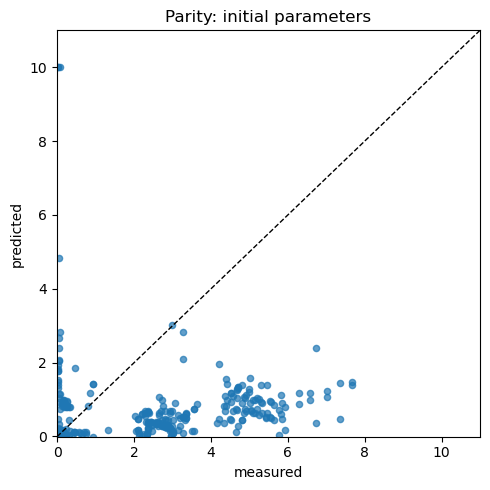

In [6]:
# Quick parity plot at initial parameters.
pv = pred0.predicted.to_numpy(dtype=float).ravel()
rv = pred0.real.to_numpy(dtype=float).ravel()
mask = ~(np.isnan(pv) | np.isnan(rv))
pv_m, rv_m = pv[mask], rv[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rv_m, pv_m, s=20, alpha=0.7)
lim_lo = min(rv_m.min(), pv_m.min()) * 0.9
lim_hi = max(rv_m.max(), pv_m.max()) * 1.1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1)
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("measured"); ax.set_ylabel("predicted")
ax.set_title("Parity: initial parameters")
fig.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "parity_init.png"), dpi=100, bbox_inches="tight")
plt.show()


## Parameter estimation



In [7]:
theta_fitted = None   # populated below if ipopt is available
obj_value = float("nan")

# The 37-param fit is rank-deficient (FIM rank ~10), so ipopt can satisfy
# tol=1e-6 only on the ~11 identifiable directions and oscillates on the rest,
# hitting max_iter.  Loosen the convergence target and add an "acceptable point"
# backstop so it terminates at a usable point with a status parmest accepts.
# NOTE: ~26 of the 37 params remain non-identifiable; their fitted values and
# confidence intervals are not meaningful (see the structural report).
est.solver_options = {
    "max_iter": 10000,
    "acceptable_iter": 10,
}
est.pest = est._make_estimator()
est.pest.tee = False   # show the ipopt log so we can confirm how it terminates

print("Running estimation (all 37 params free, %d conditions) ..." % len(CONDITIONS))
theta_series = est.estimate()
obj_value = est.obj_value
theta_fitted = {p: float(theta_series[p]) for p in theta_series.index}
print("Done. Objective value:", round(obj_value, 4))
print(pd.Series(theta_fitted).round(5).to_frame("theta_fitted").T.to_string())


Running estimation (all 37 params free, 22 conditions) ...
Done. Objective value: 53.7518
               v_max_1  Ka1_1    Ka2_1    Ka3_1   K_g6p_1  Ks_g6p_pgi  Kp_f6p_pgi   kcat_f_2  Ks_f6p_3  Ks_atp_3  Kp_fbp_3  Kp_adp_3   kcat_f_3  Ks_fbp_4  Kp_g3p_4  Kp_dhap_4  kcat_f_4    kcat_f_5  Ks_dhap_5  Kp_g3p_5  kcat_f_6  Ks_g3p_6  Ks_pi_6  Ks_nad_6  Kp_pgp_6  Kp_nadh_6  kcat_f_7  Ks_pgp_7  Ks_adp_7  Ks_3pg_7  Ks_atp_7   kcat_f_8  Ks_3pg_8  Ks_2pg_8  kcat_f_9  Ks_2pg_9  Ks_pep_9
theta_fitted  83.94182  0.003  1.09324  0.02477  13.30961     0.23561    14.13935  143.11567   0.32773    0.3466   0.33435   0.15974  211.05002   0.00003  11.42005    11.1899   3.48985  6413.58074    0.00154  11.23812  29.67304   2.21399  1.61892   0.00008  11.21294   11.19279  67.19215   0.00115   0.00115  12.47616  12.46026  200.63295   0.00036  11.25541  40.83474   0.51001  11.12738


## Post-fit matrices and diagnostics

Each block below wraps its API call in try/except so that a single failure
(e.g. covariance not available without a successful fit) does not abort the
remaining cells.  Results are saved to RESULTS_DIR regardless.


In [8]:
qcov_df = None
corr_df = None
ci_df = None


cov_df = est.covariance()
corr_df = est.correlation_matrix()
ci_df = est.confidence_intervals(alpha=0.05)
print("Covariance shape:", cov_df.shape)
print("Correlation shape:", corr_df.shape)
print("Confidence intervals (head):")
print(ci_df.head().round(4).to_string())


Covariance shape: (37, 37)
Correlation shape: (37, 37)
Confidence intervals (head):
           theta  std_err   ci_low  ci_high  cv_percent
v_max_1  83.9418   3.5886  76.9082  90.9754      4.2751
Ka1_1     0.0030   0.0017  -0.0003   0.0063     56.7417
Ka2_1     1.0932   0.1055   0.8864   1.3000      9.6509
Ka3_1     0.0248   0.0589  -0.0907   0.1403    237.8421
K_g6p_1  13.3096   1.6287  10.1174  16.5018     12.2368


In [9]:
cov_df

,v_max_1,Ka1_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,Kp_f6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,...,Ks_pgp_7,Ks_adp_7,Ks_3pg_7,Ks_atp_7,kcat_f_8,Ks_3pg_8,Ks_2pg_8,kcat_f_9,Ks_2pg_9,Ks_pep_9
v_max_1,12.877768,1.100236e-03,0.260802,-9.402133e-02,1.639705,-1.452693,3.650817e+02,-1.124502e+02,-0.373917,-0.218388,...,-7.980317e-04,0.625663,8.494189e+04,-2.880080e+04,148.831495,-2.615428e-02,-1.931118e+04,-1.615973e+02,-2.360792,189.755475
Ka1_1,0.001101,2.900897e-06,0.000079,-9.298146e-05,0.001302,-0.001804,2.874887e-01,-1.375867e-01,0.000206,-0.000188,...,-4.946679e-06,0.000234,3.456021e+01,2.795856e+01,-0.019888,2.774198e-06,-4.729378e+01,2.251867e-03,-0.000005,-0.006715
Ka2_1,0.260814,7.925778e-05,0.011132,-4.122118e-03,0.150929,-0.068117,1.433670e+01,-5.338307e+00,-0.010594,-0.016003,...,-9.819685e-05,0.016440,2.422491e+03,1.031376e+02,1.326773,-5.051039e-04,-1.352413e+03,-2.532392e+00,-0.034219,3.517700
Ka3_1,-0.094039,-9.297974e-05,-0.004122,3.471680e-03,-0.056756,0.064304,-1.163713e+01,4.959608e+00,-0.004272,0.006840,...,1.304145e-04,-0.010756,-1.433438e+03,-8.875364e+02,-0.352710,2.288020e-05,1.599862e+03,5.742131e-01,0.009026,-0.636209
K_g6p_1,1.639953,1.301923e-03,0.150932,-5.675513e-02,2.652574,-0.960369,1.845945e+02,-7.745691e+01,-0.122762,-0.297068,...,-2.784871e-03,0.163263,2.498701e+04,9.861909e+03,-14.563514,-4.455809e-03,-2.157673e+04,-7.970048e+00,-0.064128,19.783114
Ks_g6p_pgi,-1.453018,-1.803591e-03,-0.068123,6.430384e-02,-0.960390,1.214723,-2.122507e+02,9.313828e+01,-0.116708,0.114208,...,2.154649e-03,-0.185112,-2.595834e+04,-1.729733e+04,-2.247097,-9.399444e-04,3.070206e+04,7.666303e+00,0.130122,-7.282354
Kp_f6p_pgi,365.141253,2.874821e-01,14.337657,-1.163711e+01,184.597160,-212.249093,4.114483e+04,-1.647197e+04,14.367481,-18.557023,...,-2.284624e-01,38.464117,4.861920e+06,3.039792e+06,3029.785260,-7.235954e-02,-5.219176e+06,-2.725825e+03,-41.789592,3129.269576
kcat_f_2,-112.475512,-1.375851e-01,-5.338745,4.959642e+00,-77.458659,93.138414,-1.647212e+04,7.257711e+03,-8.437314,9.281784,...,1.677661e-01,-14.271762,-1.983164e+06,-1.346742e+06,-343.043527,-4.284713e-02,2.357410e+06,7.214383e+02,11.772803,-738.884617
Ks_f6p_3,-0.373878,2.059371e-04,-0.010593,-4.273023e-03,-0.122751,-0.116720,1.436981e+01,-8.438207e+00,0.116213,0.027176,...,1.710630e-03,-0.020408,9.967764e+02,2.627162e+03,-1.843021,3.462689e-03,-3.907618e+03,2.533857e+00,0.020086,-5.202128
Ks_atp_3,-0.218426,-1.875234e-04,-0.016004,6.839868e-03,-0.297069,0.114205,-1.855674e+01,9.281567e+00,0.027177,0.130238,...,2.995095e-03,-0.056495,-2.309411e+03,-2.266049e+03,12.172265,4.475579e-03,2.031569e+03,3.928495e+00,0.056811,-5.987111


In [10]:
theta_fitted

{'v_max_1': 83.9418194298652,
 'Ka1_1': 0.0030016758191021005,
 'Ka2_1': 1.093238508603856,
 'Ka3_1': 0.024773139984377617,
 'K_g6p_1': 13.309606077935191,
 'Ks_g6p_pgi': 0.2356106111555948,
 'Kp_f6p_pgi': 14.139350883380779,
 'kcat_f_2': 143.11567182688606,
 'Ks_f6p_3': 0.327733333434032,
 'Ks_atp_3': 0.3465954336284106,
 'Kp_fbp_3': 0.3343508318602717,
 'Kp_adp_3': 0.15974273991834784,
 'kcat_f_3': 211.050021774575,
 'Ks_fbp_4': 2.901679201510615e-05,
 'Kp_g3p_4': 11.420046531465442,
 'Kp_dhap_4': 11.189904353905296,
 'kcat_f_4': 3.4898512788825062,
 'kcat_f_5': 6413.580738223117,
 'Ks_dhap_5': 0.0015449279785414204,
 'Kp_g3p_5': 11.238120424048141,
 'kcat_f_6': 29.6730415017749,
 'Ks_g3p_6': 2.2139904240958734,
 'Ks_pi_6': 1.6189191615507617,
 'Ks_nad_6': 8.055300184716219e-05,
 'Kp_pgp_6': 11.21293696540618,
 'Kp_nadh_6': 11.192791462478365,
 'kcat_f_7': 67.19215482454909,
 'Ks_pgp_7': 0.0011475712274237832,
 'Ks_adp_7': 0.0011475712038147422,
 'Ks_3pg_7': 12.476160914701593,
 'Ks_

In [11]:
fim_df = None


fim_df = est.fisher_information_matrix(theta=theta_init, free_only=True)
print("FIM shape:", fim_df.shape)
eigvals = np.sort(np.linalg.eigvalsh(fim_df.to_numpy(dtype=float)))[::-1]
print("FIM eigenvalues (top 10):", eigvals[:10].round(3))
print("FIM rank estimate (eigvals > 1e-10):",
        int(np.sum(eigvals > 1e-10)))


FIM shape: (37, 37)
FIM eigenvalues (top 10): [1.44112354e+21 2.61061065e+18 7.06812610e+17 7.36871149e+16
 1.66912225e+16 4.86197409e+15 1.68294198e+15 1.21685765e+15
 4.06306596e+14 9.95528389e+13]
FIM rank estimate (eigvals > 1e-10): 28


In [12]:

_theta_for_sens = theta_fitted if theta_fitted is not None else theta_init
sens_dict = est.sensitivity_matrix(theta=_theta_for_sens, kind="both")
print("Sensitivity matrices computed for %d conditions." % len(sens_dict))
first_cond = next(iter(sens_dict))
print("  Shape for condition '%s':" % first_cond, sens_dict[first_cond].shape)


Sensitivity matrices computed for 22 conditions.
  Shape for condition 'KO03': (18, 37)


Post-fit prediction summary:
Prediction over 22 condition(s), 18 outputs (301 measured cells):
  RMSE met       = 2.707 mM
  RMSE flux      = 1.214 mmol/gDCW/h
  RMSE data_norm = 22.51 (dimensionless, column-mean normalized)
  RMSE weighted  = 160.7 (sigma units; ~1 = at noise floor)
  worst-fit outputs: C_fbp=4.99, C_3pg=2.85, C_pep=2.42

RMSE comparison:
               init    fitted
met          1.9417    2.7067
flux         3.3968    1.2145
data_norm   19.8497   22.5055
weighted   151.2708  160.7248


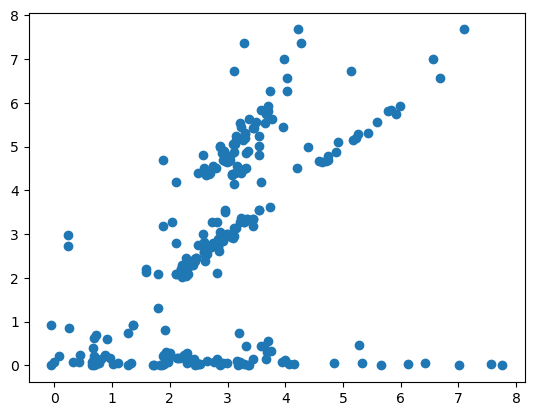

In [13]:
pred_fitted = None
rmse_fitted = None


pred_fitted = est.predict(theta=theta_fitted)
rmse_fitted = pred_fitted.rmse
print("Post-fit prediction summary:")
print(pred_fitted.summary())


# RMSE comparison table.
rmse_tbl = pd.DataFrame({
    "init": pred0.rmse,
    "fitted": rmse_fitted,
})
print("\nRMSE comparison:")
print(rmse_tbl.round(4).to_string())
pv = pred_fitted.predicted.to_numpy(dtype=float).ravel()
rv = pred_fitted.real.to_numpy(dtype=float).ravel()
plt.scatter(pv, rv)

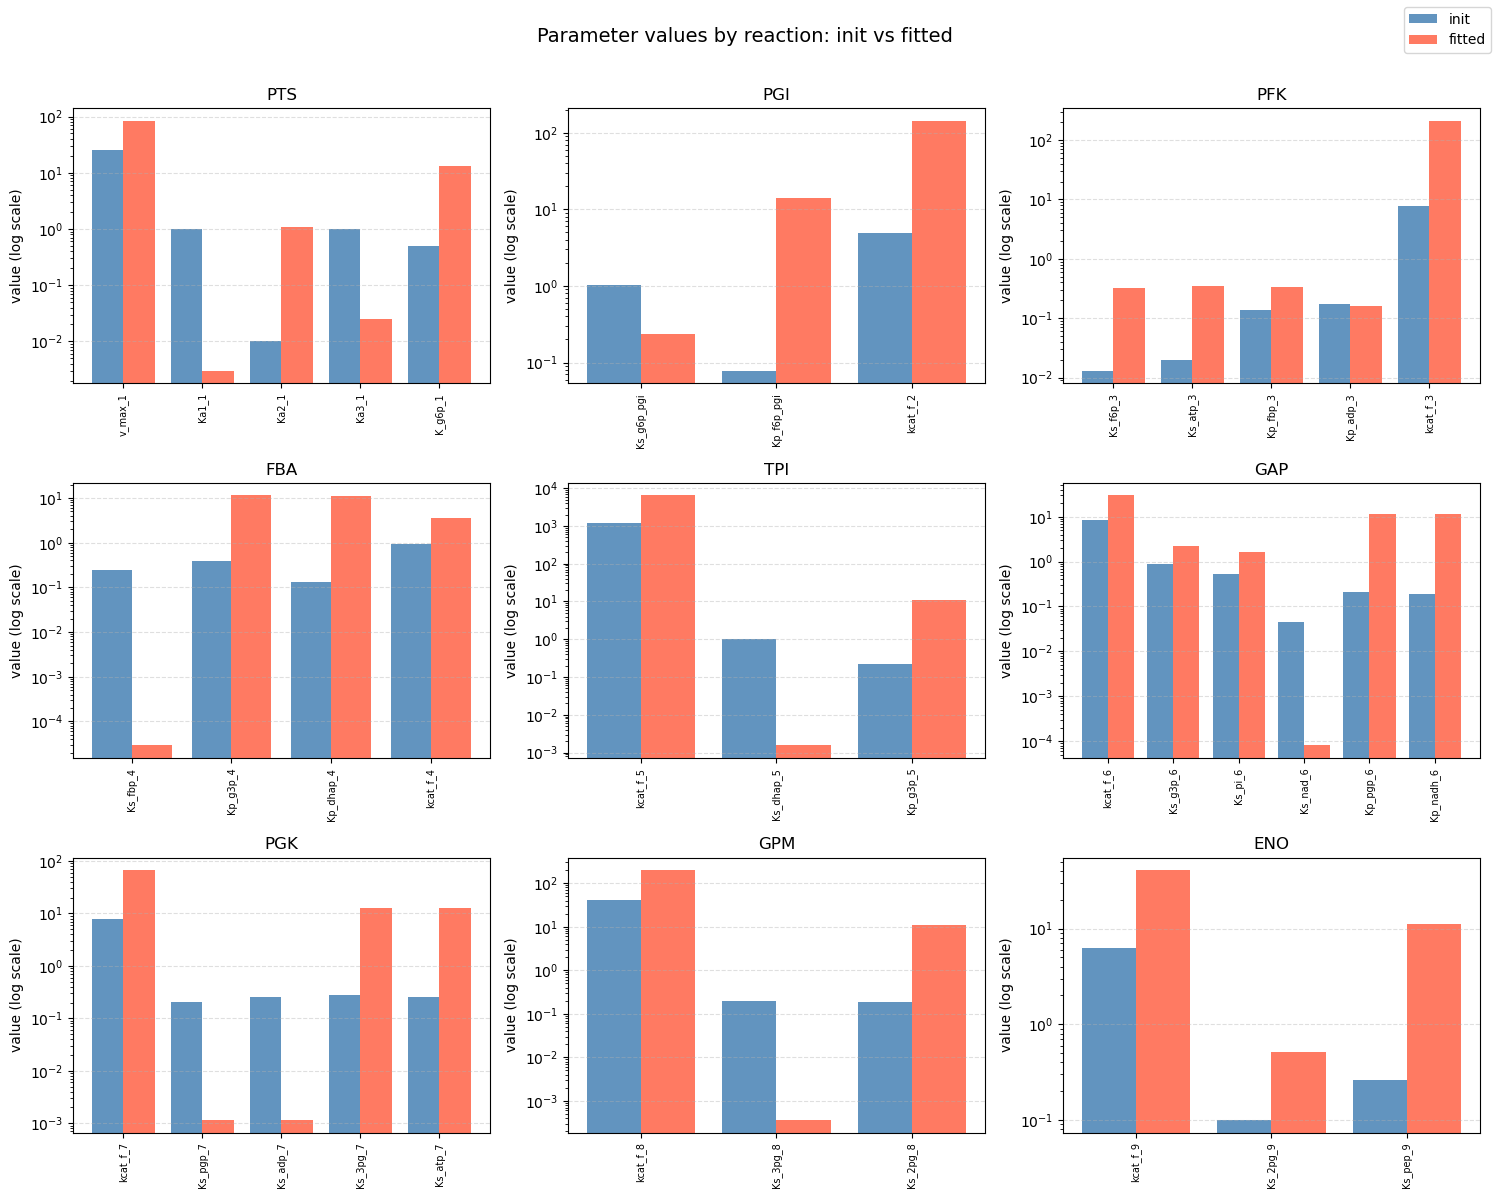

In [14]:
# Per-reaction parameter comparison: initial vs fitted (one panel per reaction).
from kinetics_noor import PARAM_RXN_MAP

reactions = list(PARAM_RXN_MAP.keys())
has_fitted = theta_fitted is not None
width = 0.4

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, rxn in zip(axes.ravel(), reactions):
    params = PARAM_RXN_MAP[rxn]
    x = np.arange(len(params))
    init_vals = [theta_init[p] for p in params]

    ax.bar(x - width / 2, init_vals, width, label="init",
           color="steelblue", alpha=0.85)

    if has_fitted:
        fitted_vals = [theta_fitted[p] for p in params]
        ax.bar(x + width / 2, fitted_vals, width, label="fitted",
               color="tomato", alpha=0.85)

    ax.set_yscale("log")
    ax.set_title(rxn.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=90, fontsize=7)
    ax.set_ylabel("value (log scale)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=10)

suptitle = "Parameter values by reaction: init vs fitted"
if not has_fitted:
    suptitle += "  (fitted unavailable -- showing init only)"

fig.suptitle(suptitle, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig_dir = os.path.join(RESULTS_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, "theta_by_reaction.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [15]:
struct_report = None


_theta_for_struct = theta_fitted if theta_fitted is not None else theta_init
struct_report = est.structural_report(theta=_theta_for_struct, corr_threshold=0.9)
print("Structural report keys:", list(struct_report.keys()))
print("\nPer-condition:")
print(struct_report["per_condition"].round(2).to_string())
print("\nIdentifiability:")
print(struct_report["identifiability"].to_string())
print("\nPer-parameter (head):")
print(struct_report["per_parameter"].head(10).round(3).to_string())


Structural report keys: ['per_condition', 'identifiability', 'per_parameter']

Per-condition:
           ss_residual  rank_A        cond_A  n_bound_active  rank_G
condition                                                           
KO03              0.00       9  1.433067e+06               0       9
KO07              0.00       9  9.420414e+05               0       9
KO18              0.00       9  9.612781e+05               0       9
KO19              0.00       9  6.890978e+05               0       9
KO24              0.00       9  4.403533e+05               0       9
KO13              0.00       9  4.756418e+05               0       9
KO17              0.00       9  4.978152e+05               0       9
KO15              0.00       9  8.628300e+06               0       9
KO05              0.00       9  1.215969e+09               0       9
KO23              0.00       9  3.138231e+06               0       9
KO16              0.00       9  8.255358e+05               0       9
KO14     

## Save all artifacts to RESULTS_DIR


In [16]:
def save_matrices(
    results_dir,
    theta_init,
    theta_sources_df,
    pred0,
    theta_fitted=None,
    pred_fitted=None,
    cov_df=None,
    corr_df=None,
    ci_df=None,
    fim_df=None,
    sens_dict=None,
    struct_report=None,
    obj_value=float("nan"),
    ipopt_available=False,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=None,
    free_params=None,
):
    """
    Save all estimation artifacts to results_dir.
    Writes CSVs, JSON, pickle, and a manifest.
    """
    os.makedirs(results_dir, exist_ok=True)

    def _csv(df, name):
        if df is not None:
            df.to_csv(os.path.join(results_dir, name))
            print("  saved", name)

    # theta_init as a single-column CSV [value]
    ti_series = pd.Series(theta_init, name="value")
    ti_series.index.name = "param"
    _csv(ti_series.to_frame(), "theta_init.csv")

    # theta_init_sources: [param, value, source]
    _csv(theta_sources_df, "theta_init_sources.csv")

    # theta_fitted
    if theta_fitted is not None:
        tf_series = pd.Series(theta_fitted, name="value")
        tf_series.index.name = "param"
        _csv(tf_series.to_frame(), "theta_fitted.csv")

    # covariance / correlation / confidence intervals
    _csv(cov_df, "covariance.csv")
    _csv(corr_df, "correlation.csv")
    _csv(ci_df, "confidence_intervals.csv")
    _csv(fim_df, "fim.csv")

    # predictions
    if pred0 is not None:
        _csv(pred0.predicted, "predictions_init.csv")
        _csv(pred0.real, "real.csv")
        with open(os.path.join(results_dir, "rmse_init.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred0.rmse.items()}, fh, indent=2)
        print("  saved rmse_init.json")

    if pred_fitted is not None:
        _csv(pred_fitted.predicted, "predictions_fitted.csv")
        with open(os.path.join(results_dir, "rmse_fitted.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred_fitted.rmse.items()}, fh, indent=2)
        print("  saved rmse_fitted.json")

    # sensitivity matrices
    if sens_dict is not None:
        sens_path = os.path.join(results_dir, "sensitivity.pkl")
        with open(sens_path, "wb") as fh:
            pickle.dump(sens_dict, fh)
        print("  saved sensitivity.pkl (%d conditions)" % len(sens_dict))

        # also save per-condition CSVs for easy inspection
        sens_dir = os.path.join(results_dir, "sensitivity")
        os.makedirs(sens_dir, exist_ok=True)
        for cond, G_df in sens_dict.items():
            G_df.to_csv(os.path.join(sens_dir, "%s.csv" % cond))
        print("  saved sensitivity/ CSVs")

    # structural report
    if struct_report is not None:
        for key, df in struct_report.items():
            if isinstance(df, pd.DataFrame):
                fname = "structural_report_%s.csv" % key
                _csv(df, fname)

    # manifest
    manifest = {
        "seed": seed,
        "sigma_log10": sigma_log10,
        "conditions": conditions or [],
        "n_conditions": len(conditions) if conditions else 0,
        "free_params": free_params or [],
        "n_free_params": len(free_params) if free_params else 0,
        "obj_value": None if not np.isfinite(obj_value) else float(obj_value),
        "ipopt_available": ipopt_available,
        "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
    }
    with open(os.path.join(results_dir, "manifest.json"), "w") as fh:
        json.dump(manifest, fh, indent=2)
    print("  saved manifest.json")
    print("All artifacts saved to:", results_dir)


save_matrices(
    results_dir=RESULTS_DIR,
    theta_init=theta_init,
    theta_sources_df=theta_sources_df,
    pred0=pred0,
    theta_fitted=theta_fitted,
    pred_fitted=pred_fitted,
    cov_df=cov_df,
    corr_df=corr_df,
    ci_df=ci_df,
    fim_df=fim_df,
    sens_dict=sens_dict,
    struct_report=struct_report,
    obj_value=obj_value,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=CONDITIONS,
    free_params=list(ALL_PARAMS),
)

  saved theta_init.csv
  saved theta_init_sources.csv
  saved theta_fitted.csv
  saved covariance.csv
  saved correlation.csv
  saved confidence_intervals.csv
  saved fim.csv
  saved predictions_init.csv
  saved real.csv
  saved rmse_init.json
  saved predictions_fitted.csv
  saved rmse_fitted.json
  saved sensitivity.pkl (22 conditions)
  saved sensitivity/ CSVs
  saved structural_report_per_condition.csv
  saved structural_report_identifiability.csv
  saved structural_report_per_parameter.csv
  saved manifest.json
All artifacts saved to: /Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/results/first_estimation


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_24320/2668424007.py:99: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
